# Analisis Kualitas Udara (Polutan) di Kawasan Gresik

## 1. Business Understanding

**Tujuan:**
Proyek ini bertujuan untuk mengekstraksi, menganalisis, dan mengetahui tren kualitas udara (tingkat polutan) di area spesifik Kabupaten Gresik selama kurun waktu satu tahun terakhir. Analisis ini menggunakan data historis yang ditarik hingga 31 Agustus 2026.

**Manfaat:**
*   **Bagi Masyarakat:** Meningkatkan kesadaran akan kualitas udara sehingga masyarakat bisa mengambil langkah preventif kesehatan (misalnya mengurangi kegiatan luar ruangan atau memakai masker saat polutan tinggi).
*   **Bagi Pemerintah:** Mengingat Gresik adalah kawasan perindustrian padat, data ini bisa menjadi landasan atau acuan untuk mengevaluasi kebijakan pengendalian emisi dari pabrik dan lalu lintas jalan.

---

## 2. Data Understanding

Data yang digunakan merupakan rangkaian *time-series* polutan udara per jam. Berikut adalah rincian fitur dan sumbernya:
*   **`time`**: Waktu pencatatan (tanggal dan jam) dari sensor.
*   **`CO` (Karbon Monoksida):** Gas beracun yang tidak memiliki warna maupun bau. **Sumber utama:** Berasal dari pembakaran yang tidak sempurna, umumnya diproduksi paling banyak oleh asap knalpot kendaraan bermotor.
*   **`NO2` (Nitrogen Dioksida):** Gas yang memiliki bau tajam menyengat dan berwarna cokelat kemerahan. **Sumber utama:** Mesin kendaraan bermotor (terutama diesel), pembangkit listrik, dan pembuangan asap pabrik.
*   **`PM2.5` & `PM10` (Particulate Matter):** Partikel udara debu atau asap yang berukuran mikroskopis (kurang dari 2,5 dan 10 mikrometer) dan dapat masuk ke saluran pernapasan. **Sumber:** Asap cerobong pabrik, debu aktivitas konstruksi, dan pembakaran terbuka.
*   **`O3` (Ozon Permukaan):** Ozon di permukaan tanah yang bisa membahayakan paru-paru. Terbentuk dari reaksi kimia antara sinar matahari dan polutan lain (seperti NO2).

**Pengecekan Data Aneh (Anomali):**
Dalam mengeksplorasi sensor alam, kita patut memperhatikan kondisi berikut:
1.  **Missing Values (NaN):** Data kosong pada jam tertentu, biasanya terjadi saat alat sedang pemeliharaan (*maintenance*).
2.  **Nilai Negatif:** Secara logika, konsentrasi gas di udara tidak mungkin di bawah 0. Jika ada nilai negatif, itu merupakan *error* sensor yang harus ditangani (diubah menjadi NaN).
3.  **Lonjakan Ekstrem (Outlier):** Nilai yang mendadak sangat tinggi dalam rentang waktu yang terlalu singkat.

---

## 3. Proses Crawling & Pemrosesan Data

Tahapan ini mencakup pengumpulan data dari API berdasarkan batas wilayah spasial, hingga pembersihan dan penyimpanan data ke dalam format CSV.

### A. Setup Batas Wilayah GeoJSON
Kita mulai dengan mendefinisikan batas poligon (*Polygon*) wilayah Gresik yang telah disiapkan, lalu mencari titik tengah (*centroid*) dari area tersebut untuk parameter API.

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Polygon

# Definisi koordinat batas wilayah (Gresik) menggunakan GeoJSON
geojson_coords = [
    [112.6568922, -7.1481289],
    [112.6482448, -7.1509091],
    [112.6525927, -7.1672063],
    [112.6657812, -7.1655766],
    [112.6568922, -7.1481289]
]

# Konversi ke bentuk Poligon
area_polygon = Polygon(geojson_coords)

# Mendapatkan koordinat pusat (centroid) untuk API
centroid_lon = area_polygon.centroid.x
centroid_lat = area_polygon.centroid.y
print(f"Titik Pusat Penarikan Data -> Latitude: {centroid_lat:.5f}, Longitude: {centroid_lon:.5f}")

Titik Pusat Penarikan Data -> Latitude: -7.15842, Longitude: 112.65617


### B. Mengunduh Data dari API
Menggunakan titik pusat tadi, kita menarik data kualitas udara secara historis selama satu tahun ke belakang.

# Setup Parameter Tanggal dan URL (Sampai 31 Agustus 2026)

In [2]:
start_date = "2025-08-31"
end_date = "2026-08-31"
url = "https://air-quality-api.open-meteo.com/v1/air-quality"

params = {
    "latitude": centroid_lat,
    "longitude": centroid_lon,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": "pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone",
    "timezone": "Asia/Jakarta"
}

# Request data

In [3]:
print("Memulai proses crawling...")
response = requests.get(url, params=params)
data = response.json()
print("Data API berhasil ditarik!")

Memulai proses crawling...


Data API berhasil ditarik!


### C. Data Preparation & Penyesuaian Urutan
Setelah data JSON ditarik dari API, kita ubah menjadi DataFrame. Kita juga akan menghapus anomali nilai negatif dan memastikan urutan data diatur dari yang terlama ke yang terbaru (ascending).

# Memasukkan data ke dalam Pandas DataFrame

In [4]:
df = pd.DataFrame(data['hourly'])
df['time'] = pd.to_datetime(df['time'])

# Mengubah nama kolom agar lebih ringkas

In [5]:
df.rename(columns={
    'carbon_monoxide': 'CO',
    'nitrogen_dioxide': 'NO2',
    'pm10': 'PM10',
    'pm2_5': 'PM2.5',
    'ozone': 'O3'
}, inplace=True)

# Membersihkan anomali: mengubah konsentrasi negatif menjadi Missing Values (NaN)

In [6]:
for col in ['PM10', 'PM2.5', 'CO', 'NO2', 'O3']:
    df.loc[df[col] < 0, col] = None

# Mengurutkan waktu secara ASCENDING agar runtun waktu rapi (Data terlama di atas)

In [7]:
df = df.sort_values(by='time', ascending=True).reset_index(drop=True)

# Menyimpan Data menjadi CSV

In [8]:
csv_filename = "polutan_gresik_2025_2026.csv"
df.to_csv(csv_filename, index=False)
print(f"Data disimpan ke dalam bentuk file: {csv_filename}")

Data disimpan ke dalam bentuk file: polutan_gresik_2025_2026.csv


# Menampilkan cuplikan data teratas

In [9]:
df.head()

,time,PM10,PM2.5,CO,NO2,O3
0,2025-08-31 00:00:00,30.7,29.5,860.0,27.3,35.0
1,2025-08-31 01:00:00,39.1,37.6,911.0,29.3,30.0
2,2025-08-31 02:00:00,49.1,47.5,1077.0,31.7,24.0
3,2025-08-31 03:00:00,55.3,53.4,1303.0,34.4,17.0
4,2025-08-31 04:00:00,58.9,56.8,1507.0,36.9,16.0


## 4. Visualisasi Grafik (Time Series)
Langkah terakhir adalah memvisualisasikan data runtun waktu yang telah bersih untuk melihat pergerakan tren kualitas udaranya.

### A. Grafik Gas Emisi (CO dan NO2)
Kita me-resample datanya menjadi rata-rata harian agar grafik lebih mudah dibaca dan tidak terlalu menumpuk.

# Resample data per jam menjadi rata-rata harian (D = Daily)

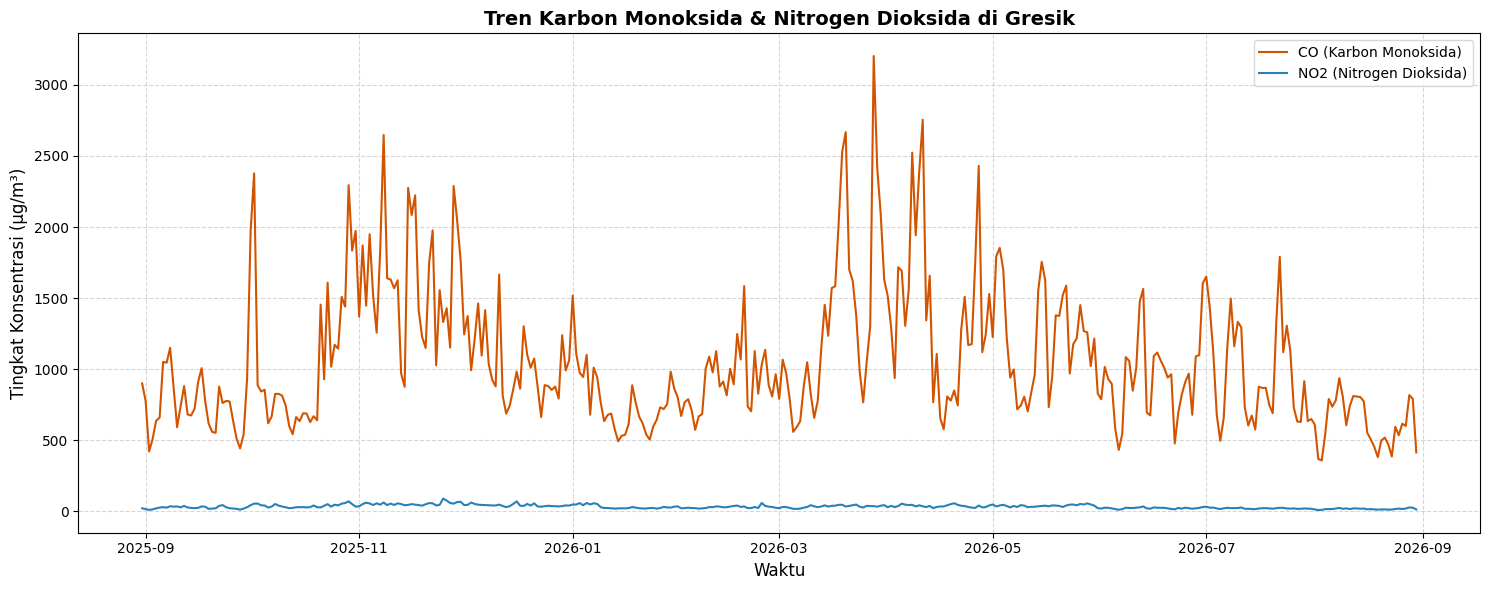

In [10]:
df_daily = df.resample('D', on='time').mean().reset_index()

# Konfigurasi kanvas Matplotlib
plt.figure(figsize=(15, 6))

# Plot Garis untuk Karbon Monoksida dan Nitrogen Dioksida
sns.lineplot(data=df_daily, x='time', y='CO', label='CO (Karbon Monoksida)', color='#d35400')
sns.lineplot(data=df_daily, x='time', y='NO2', label='NO2 (Nitrogen Dioksida)', color='#2980b9')

# Styling Grafik
plt.title('Tren Karbon Monoksida & Nitrogen Dioksida di Gresik', fontsize=14, fontweight='bold')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Tingkat Konsentrasi (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

### B. Grafik Partikel Berbahaya (PM10 dan PM2.5)
Partikulat sangat penting dipantau di wilayah pabrik dan kendaraan berat karena bentuk fisiknya berupa debu mikro yang berbahaya bagi pernapasan.

# Konfigurasi kanvas Matplotlib

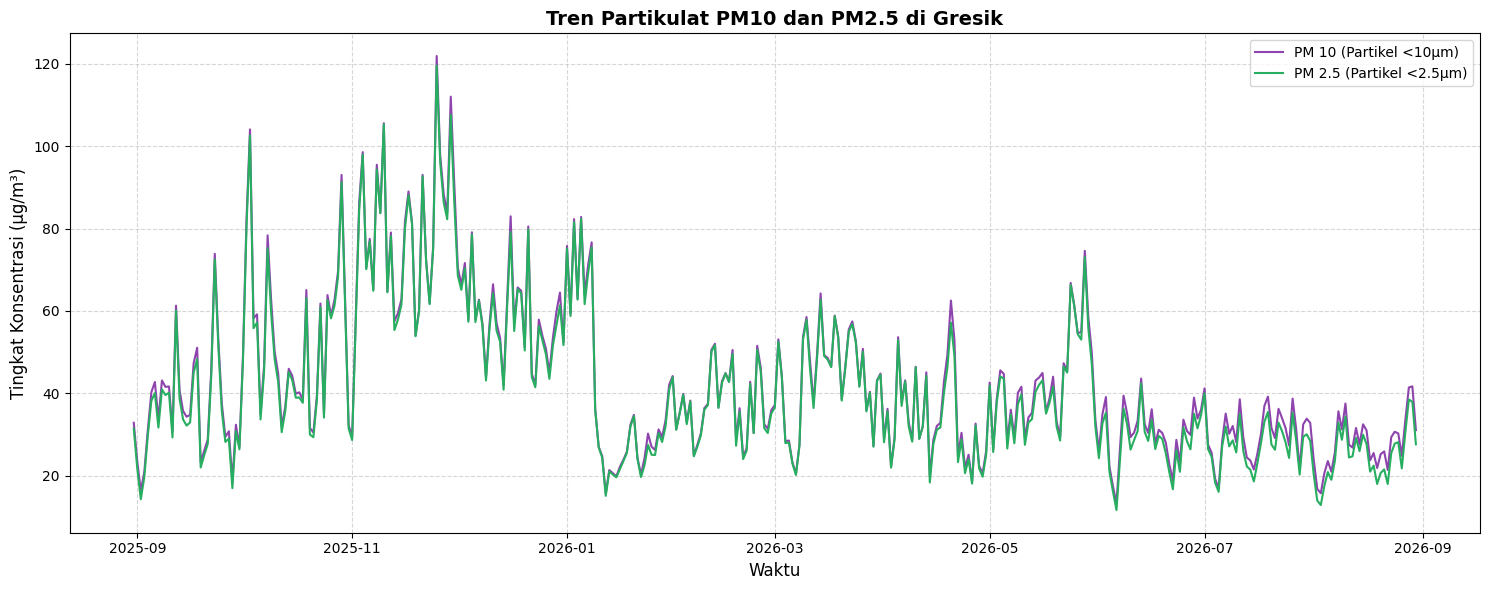

In [11]:
plt.figure(figsize=(15, 6))

# Plot Garis untuk Partikulat
sns.lineplot(data=df_daily, x='time', y='PM10', label='PM 10 (Partikel <10µm)', color='#8e44ad')
sns.lineplot(data=df_daily, x='time', y='PM2.5', label='PM 2.5 (Partikel <2.5µm)', color='#27ae60')

# Styling Grafik
plt.title('Tren Partikulat PM10 dan PM2.5 di Gresik', fontsize=14, fontweight='bold')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Tingkat Konsentrasi (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()